# Q2 — Optical Properties of Ice Clouds (v2 processing, December 2025)

**Research question:** What are the optical properties (linear depolarization ratio, lidar ratio) of tropospheric ice clouds detected by EarthCARE in December 2025?

**Source:** `ATL_EBD_2A_v2` December 2025 latheight file (ATL-TC ice mask applied, 1° × 100 m grid)  
**Occurrence overlay:** `combined_all` December 2025 (`atl_tc_occurrence`), interpolated onto EBD v2 height grid

**Tropospheric filter:** H ≤ 15 km; cells where mean ice temperature > 0 °C excluded (retrieval errors)

In [374]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

In [375]:
BASE    = Path("/Users/tobiasraucher/Python/KNMI")
OUT_DIR = BASE / "output/figures"
OUT_DIR.mkdir(exist_ok=True)

EBD_FILE     = BASE / "data/v2_data/ATL_EBD_2A_v2_1.0deg_20251201_20251231_latheight.nc"
EBD_EXT_FILE = BASE / "data/v2_data/ATL_EBD_2A_ext_bsc_v2_1.0deg_20251201_20251231_latheight.nc"
OCC_FILE     = BASE / "output/combined_all_1.0deg_20251201_20251231_latheight.nc"

MIN_COUNT  = 50     # minimum ice-pixel samples per grid cell
H_MIN_KM   = 4.0
H_MAX_KM   = 20.0

OCC_LEVELS = [0.05, 0.10, 0.20, 0.30]

# ── Optional temperature mask ──────────────────────────────────────────────────
APPLY_TEMP_MASK = True
T_MAX_K         = 260.0   # K

In [376]:
from scipy.interpolate import interp1d

# ── Load EBD v2 ────────────────────────────────────────────────────────────────
ds_ebd = xr.open_dataset(EBD_FILE)
lat    = ds_ebd["latitude"].values
h_m    = ds_ebd["height"].values          # metres, ascending
h_km   = h_m / 1000.0

h_mask = (h_km >= H_MIN_KM) & (h_km <= H_MAX_KM)
h_plot = h_km[h_mask]

depol       = ds_ebd["depol_ratio_mean"].values[:, h_mask].copy()
depol_count = ds_ebd["depol_ratio_count"].values[:, h_mask].copy()
lr          = ds_ebd["lidar_ratio_mean"].values[:, h_mask].copy()
lr_count    = ds_ebd["lidar_ratio_count"].values[:, h_mask].copy()
ds_ebd.close()

# ── Load occurrence + extinction + temperature from original combined file ─────
ds_occ    = xr.open_dataset(OCC_FILE)
occ_raw   = ds_occ["atl_tc_occurrence"].values
tot_raw   = ds_occ["atl_tc_total_count"].values
ext_raw   = ds_occ["extinction_mean"].values
ice_n_raw = ds_occ["atl_tc_ice_count"].values
ice_t_raw = ds_occ["atl_tc_temperature"].values   # K, mean temp of ice pixels
h_occ_km  = ds_occ["height"].values / 1000.0      # descending
ds_occ.close()

# Sort to ascending height so interp1d works correctly
sort_idx  = np.argsort(h_occ_km)
h_occ_asc = h_occ_km[sort_idx]

occ_interp = np.full((len(lat), h_mask.sum()), np.nan)
tot_interp = np.full((len(lat), h_mask.sum()), np.nan)
ext_interp = np.full((len(lat), h_mask.sum()), np.nan)
icn_interp = np.full((len(lat), h_mask.sum()), np.nan)
ice_t_interp = np.full((len(lat), h_mask.sum()), np.nan)

for i in range(len(lat)):
    occ_asc = occ_raw[i, sort_idx]
    tot_asc = tot_raw[i, sort_idx]
    ext_asc = ext_raw[i, sort_idx]
    icn_asc = ice_n_raw[i, sort_idx]
    ice_t_asc = ice_t_raw[i, sort_idx]

    finite = np.isfinite(occ_asc) & np.isfinite(tot_asc)
    if finite.sum() < 2:
        continue

    def _interp(y):
        fin = finite & np.isfinite(y)
        if fin.sum() < 2:
            return np.full(h_plot.shape, np.nan)
        return interp1d(h_occ_asc[fin], y[fin],
                        kind="linear", bounds_error=False, fill_value=np.nan)(h_plot)

    occ_interp[i, :]   = _interp(occ_asc)
    tot_interp[i, :]   = _interp(tot_asc)
    ext_interp[i, :]   = _interp(ext_asc)
    icn_interp[i, :]   = _interp(icn_asc)
    ice_t_interp[i, :] = _interp(ice_t_asc)

# ── Shared mask: require MIN_COUNT for BOTH v2 variables ──────────────────────
shared_bad = (depol_count < MIN_COUNT) | (lr_count < MIN_COUNT)

# ── Optional temperature mask (T > T_MAX_K → exclude) ─────────────────────────
if APPLY_TEMP_MASK:
    temp_bad   = ice_t_interp > T_MAX_K
    shared_bad = shared_bad | temp_bad
    n_masked   = int(temp_bad.sum())
    print(f"Temperature mask (T > {T_MAX_K} K): {n_masked:,} additional cells excluded")

occ   = np.where(tot_interp < MIN_COUNT, np.nan, occ_interp)
depol = np.where(shared_bad, np.nan, depol)
lr    = np.where(shared_bad, np.nan, lr)
ext   = np.where(icn_interp < MIN_COUNT, np.nan, ext_interp)

print(f"Grid  : {len(lat)} lat × {h_plot[0]:.1f}–{h_plot[-1]:.1f} km  ({h_mask.sum()} height levels)")
print(f"Cells with valid occurrence  : {np.isfinite(occ).sum():,}")
print(f"Cells with valid depol ratio : {np.isfinite(depol).sum():,}")
print(f"Cells with valid lidar ratio : {np.isfinite(lr).sum():,}")
print(f"Cells with valid extinction  : {np.isfinite(ext).sum():,}")
assert (np.isfinite(depol) == np.isfinite(lr)).all(), "Mask mismatch!"
print("Shared mask confirmed: depol and lidar ratio have identical coverage.")

Temperature mask (T > 260.0 K): 1,783 additional cells excluded
Grid  : 180 lat × 4.0–20.0 km  (161 height levels)
Cells with valid occurrence  : 26,880
Cells with valid depol ratio : 14,373
Cells with valid lidar ratio : 14,373
Cells with valid extinction  : 17,331
Shared mask confirmed: depol and lidar ratio have identical coverage.


In [377]:
def cross_section(data, title, cbar_label, cmap="viridis",
                  vmin=None, vmax=None, log_scale=False, quantile_norm=False,
                  occ_color="black", occ_thresh=0.05, fname=None):
    """Lat-height pcolormesh with occurrence contour overlay."""
    fig, ax = plt.subplots(figsize=(10, 5))

    valid = data[np.isfinite(data)]

    if quantile_norm:
        boundaries = np.unique(np.nanpercentile(valid, np.linspace(2, 98, 21)))
        norm = mcolors.BoundaryNorm(boundaries, ncolors=256)
        mesh = ax.pcolormesh(lat, h_plot, data.T, cmap=cmap, norm=norm, shading="auto")
        plt.colorbar(mesh, ax=ax, label=cbar_label, pad=0.02, fraction=0.046)
    elif log_scale:
        inside = data[occ >= occ_thresh]
        inside = inside[np.isfinite(inside) & (inside > 0)]
        vmin_  = vmin if vmin is not None else np.nanpercentile(inside, 2)
        vmax_  = vmax if vmax is not None else np.nanpercentile(inside, 98)
        norm   = mcolors.LogNorm(vmin=vmin_, vmax=vmax_)
        mesh   = ax.pcolormesh(lat, h_plot, data.T, cmap=cmap, norm=norm, shading="auto")
        plt.colorbar(mesh, ax=ax, label=cbar_label, pad=0.02, fraction=0.046)
    else:
        vmin_  = vmin if vmin is not None else 0
        vmax_  = vmax if vmax is not None else np.nanpercentile(valid, 98)
        mesh   = ax.pcolormesh(lat, h_plot, data.T, cmap=cmap,
                               vmin=vmin_, vmax=vmax_, shading="auto")
        plt.colorbar(mesh, ax=ax, label=cbar_label, pad=0.02, fraction=0.046)

    cs = ax.contour(lat, h_plot, occ.T, levels=OCC_LEVELS,
                    colors=occ_color, linewidths=0.7)
    ax.clabel(cs, fmt="%.2f", fontsize=7, inline=True)

    ax.set_xlabel("Latitude (°)", fontsize=10)
    ax.set_ylabel("Height (km)", fontsize=10)
    ax.set_xlim(-90, 90)
    ax.set_xticks(range(-90, 91, 30))
    ax.set_ylim(H_MIN_KM, H_MAX_KM)
    ax.set_facecolor("lightgrey")
    ax.set_title(title, fontsize=11)

    plt.tight_layout()
    if fname:
        plt.savefig(OUT_DIR / fname, dpi=300, bbox_inches="tight")
        print(f"Saved {fname}")
    plt.show()


def weighted_stats(arr, weights, label):
    """Print weighted descriptive statistics."""
    mask  = np.isfinite(arr) & np.isfinite(weights) & (weights > 0)
    v, w  = arr[mask], weights[mask]
    wmean = np.average(v, weights=w)
    wvar  = np.average((v - wmean) ** 2, weights=w)

    def wp(p):
        idx  = np.argsort(v)
        cumw = np.cumsum(w[idx]) / w.sum()
        return np.interp(p / 100, cumw, v[idx])

    print(f"  {label}")
    print(f"    n cells : {mask.sum():,}   total pixels : {w.sum():,.0f}")
    print(f"    min / max: {v.min():.4g} / {v.max():.4g}")
    print(f"    w.mean   : {wmean:.4g}   w.std: {np.sqrt(wvar):.4g}")
    print(f"    p5 / p25 / p50 / p75 / p95: "
          f"{wp(5):.4g} / {wp(25):.4g} / {wp(50):.4g} / {wp(75):.4g} / {wp(95):.4g}")
    print()

## Figure M3 — Linear depolarization ratio

Saved M3_v2_depol_latheight.png


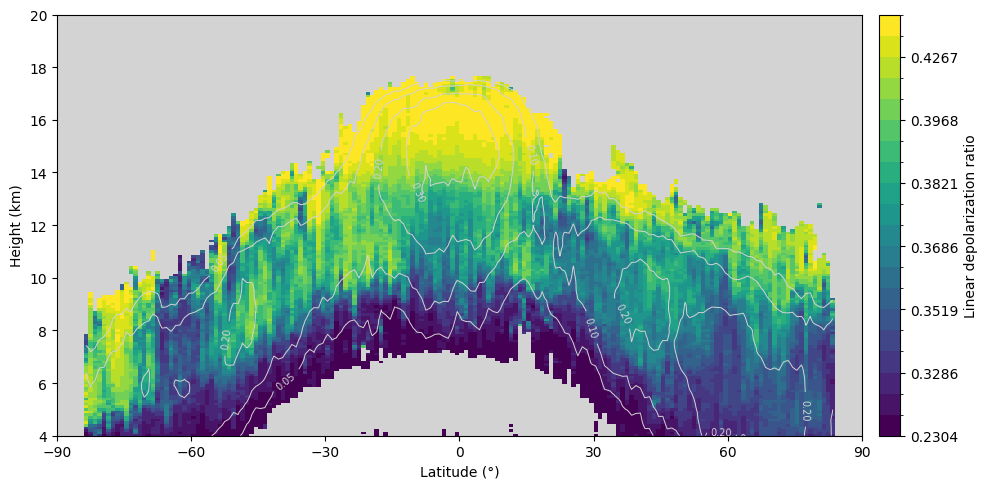

In [378]:
cross_section(
    depol,
    title="",
    cbar_label="Linear depolarization ratio",
    cmap="viridis",
    quantile_norm=True,
    occ_color="lightgrey",
    fname="M3_v2_depol_latheight.png",
)

In [379]:
weighted_stats(depol, depol_count, "Linear depolarization ratio")

  Linear depolarization ratio
    n cells : 14,373   total pixels : 14,340,056
    min / max: 0.1304 / 0.58
    w.mean   : 0.3727   w.std: 0.03792
    p5 / p25 / p50 / p75 / p95: 0.3195 / 0.3495 / 0.3715 / 0.3914 / 0.4441



## Figure M3b — Linear depolarization ratio (linear scale, clipped)

Saved M3b_v2_depol_linear_latheight.png


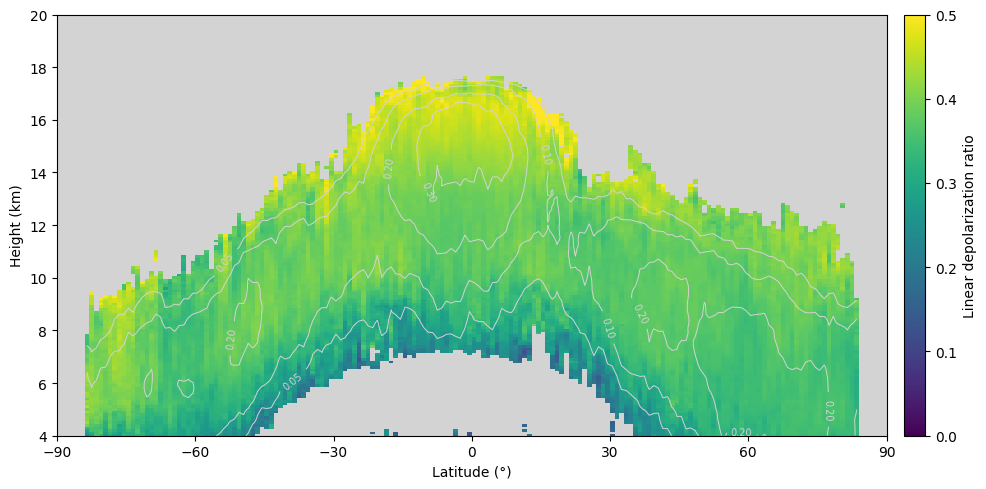

In [380]:
cross_section(
    depol,
    title="",
    cbar_label="Linear depolarization ratio",
    cmap="viridis",
    vmin=0.0,
    vmax=0.5,
    occ_color="lightgrey",
    fname="M3b_v2_depol_linear_latheight.png",
)

## Figure M4 — Lidar ratio

Saved M4_v2_lidar_ratio_latheight.png


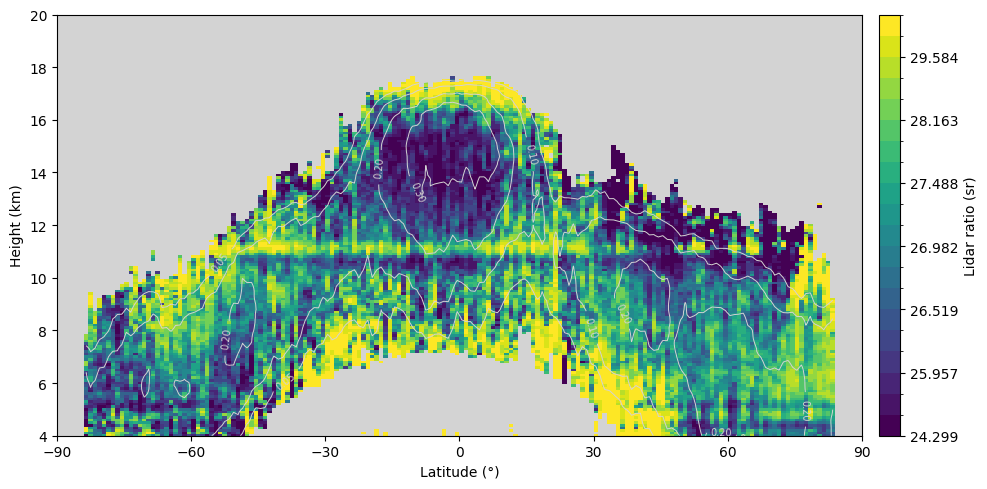

In [381]:
cross_section(
    lr,
    title="",
    cbar_label="Lidar ratio (sr)",
    cmap="viridis",
    quantile_norm=True,
    occ_color="lightgrey",
    fname="M4_v2_lidar_ratio_latheight.png",
)

In [382]:
weighted_stats(lr, lr_count, "Lidar ratio (sr)")

  Lidar ratio (sr)
    n cells : 14,373   total pixels : 20,811,486
    min / max: 14.42 / 62.48
    w.mean   : 27.25   w.std: 1.713
    p5 / p25 / p50 / p75 / p95: 25.29 / 26.28 / 27.02 / 27.87 / 29.74



## Figure M4b — Lidar ratio (linear scale, clipped)

Saved M4b_v2_lidar_ratio_linear_latheight.png


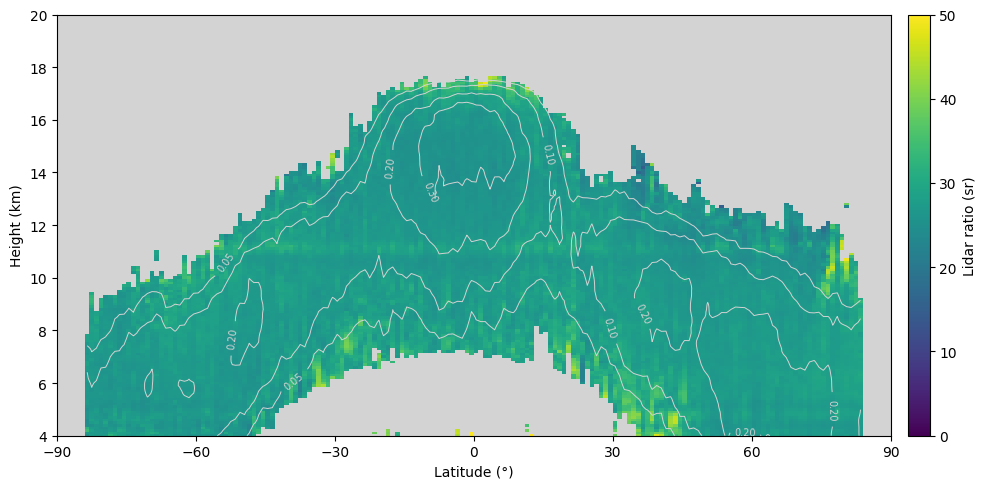

In [383]:
cross_section(
    lr,
    title="",
    cbar_label="Lidar ratio (sr)",
    cmap="viridis",
    vmin=0,
    vmax=50,
    occ_color="lightgrey",
    fname="M4b_v2_lidar_ratio_linear_latheight.png",
)

## Figure M4c — Extinction coefficient (direct retrieval, v1.5)

Saved M4c_extinction_latheight.png


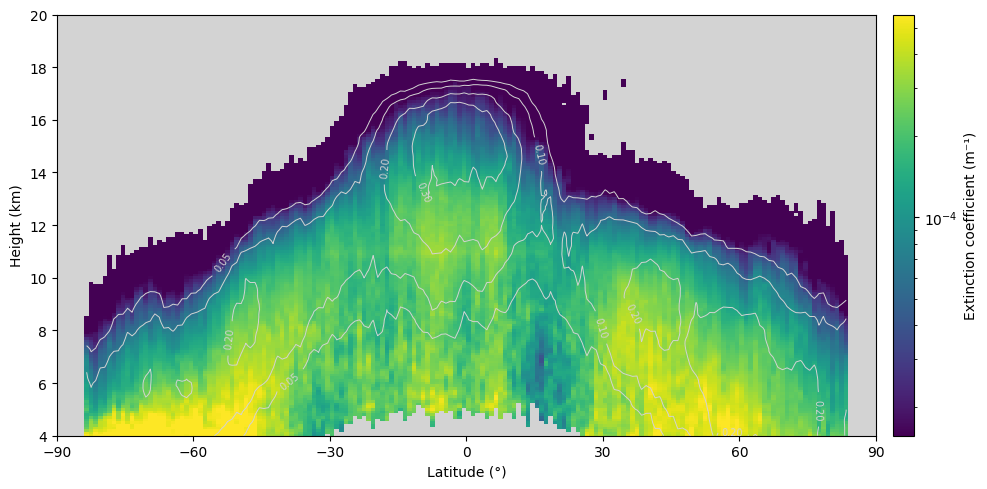

In [384]:
cross_section(
    ext,
    title="",
    cbar_label="Extinction coefficient (m⁻¹)",
    cmap="viridis",
    log_scale=True,
    occ_color="lightgrey",
    fname="M4c_extinction_latheight.png",
)

In [385]:
weighted_stats(ext, icn_interp, "Extinction coefficient (m⁻¹)")

  Extinction coefficient (m⁻¹)
    n cells : 17,331   total pixels : 111,547,807
    min / max: 1.336e-08 / 0.001026
    w.mean   : 0.0001956   w.std: 0.0001348
    p5 / p25 / p50 / p75 / p95: 2.255e-05 / 9.323e-05 / 0.0001785 / 0.0002647 / 0.0004411



## Load v2 extinction & backscatter

In [386]:
# ── Load v2 extinction & backscatter ──────────────────────────────────────────
ds_eb = xr.open_dataset(EBD_EXT_FILE)
ext_v2_raw = ds_eb["extinction_mean"].values[:, h_mask].copy()
bsc_v2_raw = ds_eb["backscatter_mean"].values[:, h_mask].copy()
ext_v2_cnt = ds_eb["extinction_count"].values[:, h_mask].copy()
bsc_v2_cnt = ds_eb["backscatter_count"].values[:, h_mask].copy()
ds_eb.close()

# Shared mask: both variables must meet MIN_COUNT; apply temperature mask if active
eb_shared_bad = (ext_v2_cnt < MIN_COUNT) | (bsc_v2_cnt < MIN_COUNT)
if APPLY_TEMP_MASK:
    eb_shared_bad = eb_shared_bad | (ice_t_interp > T_MAX_K)

ext_v2 = np.where(eb_shared_bad, np.nan, ext_v2_raw)
bsc_v2 = np.where(eb_shared_bad, np.nan, bsc_v2_raw)

print(f"Cells with valid extinction (v2) : {np.isfinite(ext_v2).sum():,}")
print(f"Cells with valid backscatter (v2): {np.isfinite(bsc_v2).sum():,}")
assert (np.isfinite(ext_v2) == np.isfinite(bsc_v2)).all(), "Mask mismatch!"

Cells with valid extinction (v2) : 12,281
Cells with valid backscatter (v2): 12,281


## Figure M4d — Extinction coefficient (v2, SNR-filtered)

Saved M4d_v2_extinction_latheight.png


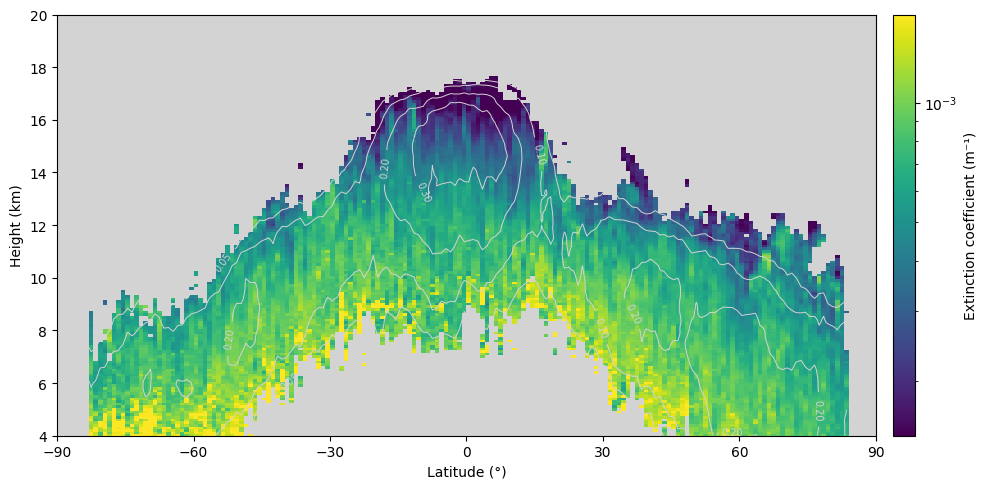

  Extinction coefficient (m⁻¹)
    n cells : 12,281   total pixels : 5,397,646
    min / max: 4.646e-05 / 0.00396
    w.mean   : 0.0006847   w.std: 0.0002738
    p5 / p25 / p50 / p75 / p95: 0.0002632 / 0.0005095 / 0.0006777 / 0.0008379 / 0.001095



In [387]:
cross_section(
    ext_v2,
    title="",
    cbar_label="Extinction coefficient (m⁻¹)",
    cmap="viridis",
    log_scale=True,
    occ_color="lightgrey",
    fname="M4d_v2_extinction_latheight.png",
)
weighted_stats(ext_v2, ext_v2_cnt, "Extinction coefficient (m⁻¹)")

## Figure M4e — Particle backscatter coefficient (v2, SNR-filtered)

Saved M4e_v2_backscatter_latheight.png


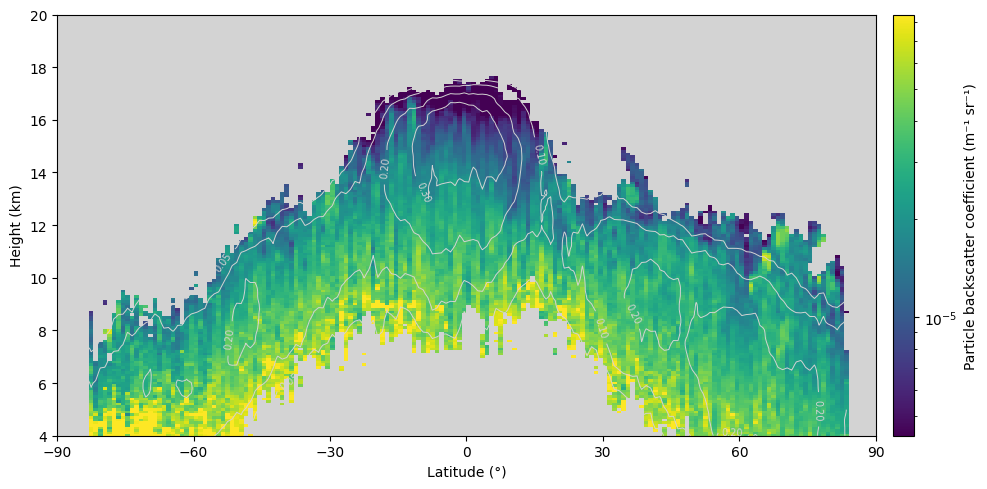

  Particle backscatter coefficient (m⁻¹ sr⁻¹)
    n cells : 12,281   total pixels : 3,937,874
    min / max: 1.342e-06 / 0.0002266
    w.mean   : 2.783e-05   w.std: 1.637e-05
    p5 / p25 / p50 / p75 / p95: 7.348e-06 / 1.749e-05 / 2.591e-05 / 3.433e-05 / 5.502e-05



In [388]:
cross_section(
    bsc_v2,
    title="",
    cbar_label="Particle backscatter coefficient (m⁻¹ sr⁻¹)",
    cmap="viridis",
    log_scale=True,
    occ_color="lightgrey",
    fname="M4e_v2_backscatter_latheight.png",
)
weighted_stats(bsc_v2, bsc_v2_cnt, "Particle backscatter coefficient (m⁻¹ sr⁻¹)")

## Figure M4f — Scatter: extinction vs backscatter (v2)

N cells          : 12,281
Pearson r (log)  : 0.9437
Spearman rho     : 0.9329
Log-log fit      : log10(BSC) = 1.133 x log10(EXT) + -0.976
Implied lidar ratio median = 25.4 sr
Saved M4f_ext_vs_bsc_scatter.png


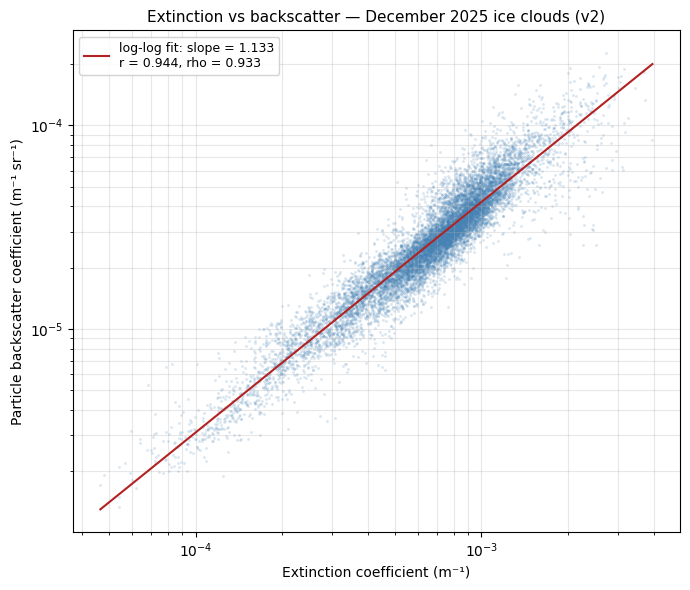

In [389]:
# ── Flatten, keep cells valid for both ───────────────────────────────────────
mask_eb = np.isfinite(ext_v2) & np.isfinite(bsc_v2)
e_sc = ext_v2[mask_eb]
b_sc = bsc_v2[mask_eb]

# ── Stats ─────────────────────────────────────────────────────────────────────
from scipy import stats as sp_stats

r_eb,   _ = sp_stats.pearsonr(np.log10(e_sc), np.log10(b_sc))
rho_eb, _ = sp_stats.spearmanr(e_sc, b_sc)
sl_eb, ic_eb, *_ = sp_stats.linregress(np.log10(e_sc), np.log10(b_sc))

print(f"N cells          : {len(e_sc):,}")
print(f"Pearson r (log)  : {r_eb:.4f}")
print(f"Spearman rho     : {rho_eb:.4f}")
print(f"Log-log fit      : log10(BSC) = {sl_eb:.3f} x log10(EXT) + {ic_eb:.3f}")
print(f"Implied lidar ratio median = {np.median(e_sc/b_sc):.1f} sr")

# ── Plot (log-log) ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(e_sc, b_sc, s=4, alpha=0.2, linewidths=0, color="steelblue")

# Regression line in log-log space
e_fit = np.logspace(np.log10(e_sc.min()), np.log10(e_sc.max()), 200)
b_fit = 10**ic_eb * e_fit**sl_eb
fit_label = f"log-log fit: slope = {sl_eb:.3f}\nr = {r_eb:.3f}, rho = {rho_eb:.3f}"
ax.plot(e_fit, b_fit, color="firebrick", linewidth=1.5, label=fit_label)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Extinction coefficient (m\u207b\xb9)", fontsize=10)
ax.set_ylabel("Particle backscatter coefficient (m\u207b\xb9 sr\u207b\xb9)", fontsize=10)
ax.legend(fontsize=9, framealpha=0.85)
ax.set_title("Extinction vs backscatter — December 2025 ice clouds (v2)", fontsize=11)
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "M4f_ext_vs_bsc_scatter.png", dpi=300, bbox_inches="tight")
print("Saved M4f_ext_vs_bsc_scatter.png")
plt.show()

## Figure M5 — Vertical profiles by latitude band

Zonal-mean profiles of depolarization ratio and lidar ratio for three latitude bands.  
Shading shows ±1 std of the cell-mean values (unweighted across latitude band).

/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_48283/3656017774.py:17: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(sub, axis=0)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved M5_v2_optics_profiles.png


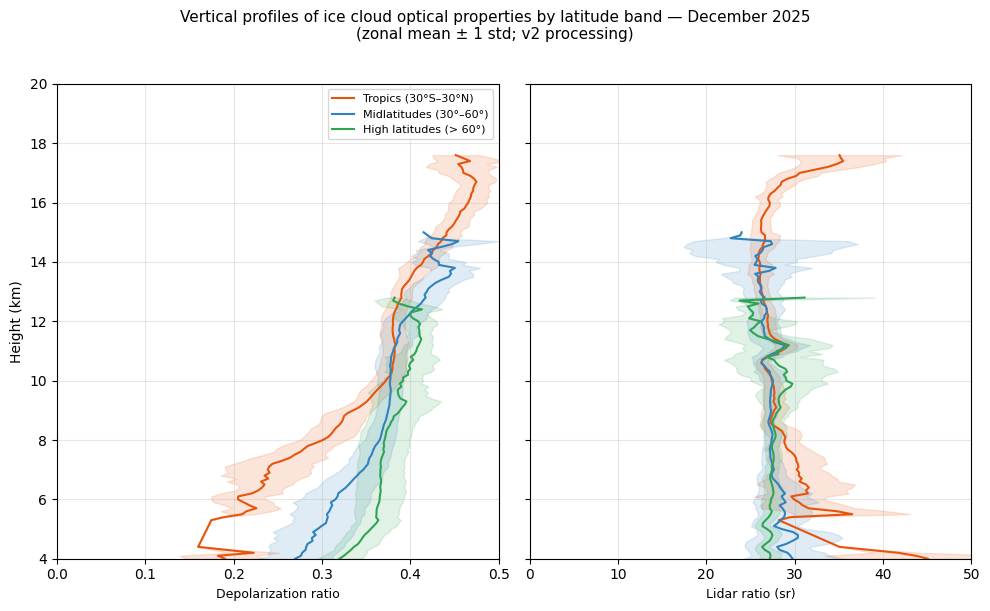

In [390]:
BANDS = [
    ("Tropics (30°S–30°N)",      (np.abs(lat) <= 30),                          "#e6550d"),
    ("Midlatitudes (30°–60°)",   ((np.abs(lat) > 30) & (np.abs(lat) <= 60)),   "#3182bd"),
    ("High latitudes (> 60°)",   (np.abs(lat) > 60),                           "#31a354"),
]

panels = [
    (depol, "Depolarization ratio", False, 0.0,  0.5),
    (lr,    "Lidar ratio (sr)",     False, 0,    50),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

for ax, (data, xlabel, use_log, xmin, xmax) in zip(axes, panels):
    for label, mask, color in BANDS:
        sub  = data[mask, :]          # (n_lat_in_band, n_heights)
        mean = np.nanmean(sub, axis=0)
        std  = np.nanstd(sub,  axis=0)
        valid = np.isfinite(mean)

        ax.plot(mean[valid], h_plot[valid], color=color, linewidth=1.5, label=label)
        ax.fill_betweenx(h_plot[valid],
                         mean[valid] - std[valid],
                         mean[valid] + std[valid],
                         color=color, alpha=0.15)

    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylim(H_MIN_KM, H_MAX_KM)
    ax.grid(True, alpha=0.3)
    if xmin is not None:
        ax.set_xlim(left=xmin)
    if xmax is not None:
        ax.set_xlim(right=xmax)

axes[0].set_ylabel("Height (km)", fontsize=10)
axes[0].legend(fontsize=8, loc="upper right", framealpha=0.8)

fig.suptitle(
    "Vertical profiles of ice cloud optical properties by latitude band — December 2025\n"
    "(zonal mean ± 1 std; v2 processing)",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "M5_v2_optics_profiles.png", dpi=300, bbox_inches="tight")
print("Saved M5_v2_optics_profiles.png")
plt.show()

## Figure M6 — Scatter: depolarization ratio vs lidar ratio

N cells       : 14,373
Pearson  r    : -0.2722   p = 0.00e+00
Spearman rho  : -0.3183   p = 0.00e+00
Linear fit    : LR = -12.56 × depol + 32.22  (sr)
Saved M6_depol_vs_lr_scatter.png


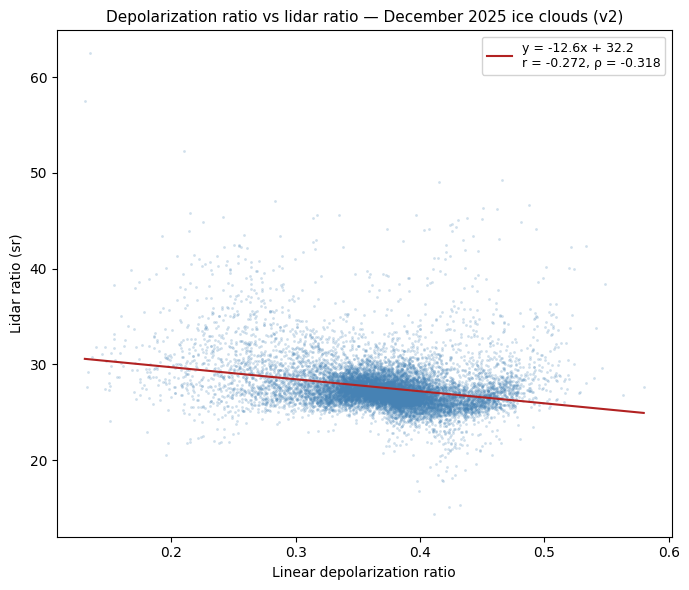

In [391]:
from scipy import stats as sp_stats

# ── Flatten to 1-D, keep only cells valid for both ────────────────────────────
mask_sc = np.isfinite(depol) & np.isfinite(lr)
d_sc    = depol[mask_sc]
l_sc    = lr[mask_sc]

# ── Statistics ────────────────────────────────────────────────────────────────
r, p      = sp_stats.pearsonr(d_sc, l_sc)
rho, p_sp = sp_stats.spearmanr(d_sc, l_sc)
slope, intercept, *_ = sp_stats.linregress(d_sc, l_sc)

print(f"N cells       : {len(d_sc):,}")
print(f"Pearson  r    : {r:.4f}   p = {p:.2e}")
print(f"Spearman rho  : {rho:.4f}   p = {p_sp:.2e}")
print(f"Linear fit    : LR = {slope:.2f} × depol + {intercept:.2f}  (sr)")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(d_sc, l_sc, s=4, alpha=0.25, linewidths=0, color="steelblue")

# Regression line
x_fit = np.array([d_sc.min(), d_sc.max()])
ax.plot(x_fit, slope * x_fit + intercept, color="firebrick", linewidth=1.5,
        label=f"y = {slope:.1f}x + {intercept:.1f}\nr = {r:.3f}, ρ = {rho:.3f}")

ax.set_xlabel("Linear depolarization ratio", fontsize=10)
ax.set_ylabel("Lidar ratio (sr)", fontsize=10)
ax.legend(fontsize=9, framealpha=0.85)
ax.set_title("Depolarization ratio vs lidar ratio — December 2025 ice clouds (v2)", fontsize=11)

plt.tight_layout()
plt.savefig(OUT_DIR / "M6_depol_vs_lr_scatter.png", dpi=300, bbox_inches="tight")
print("Saved M6_depol_vs_lr_scatter.png")
plt.show()

## Figure M7 — Scatter by temperature regime

Zone                                       N   Pearson r   Spearman ρ  LR = a·δ + b
-------------------------------------------------------------------------------------
  Retrieval error (> 0 °C)                 0  (too few points)
  Mixed phase (0 to −20 °C)             1098     -0.0718      -0.0990  LR = -6.8·δ + 31.9
  Mixed phase (−20 to −38 °C)           4222     -0.2995      -0.2352  LR = -16.9·δ + 33.4
  Pure ice (−38 to −60 °C)              5571     -0.2638      -0.3387  LR = -15.4·δ + 33.2
  Deep convective (< −60 °C)            3466      0.2120       0.2605  LR = 20.0·δ + 18.5

Saved M7_depol_vs_lr_temp_zones.png


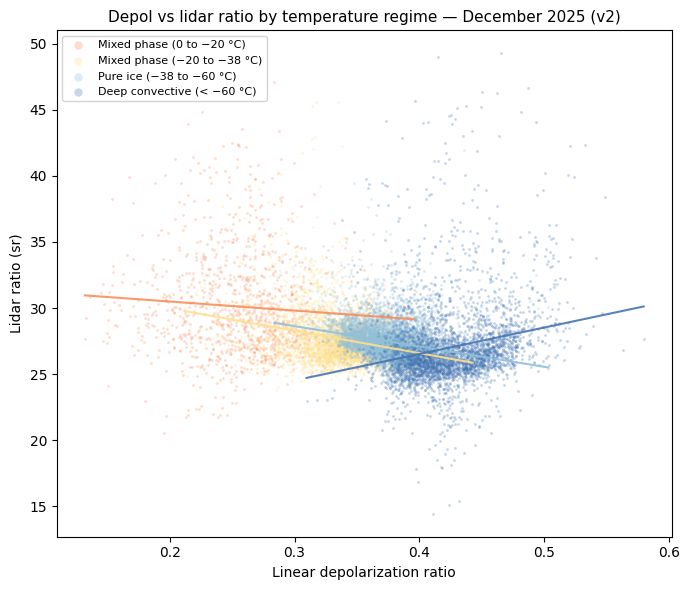

In [392]:
# ── Load temperature on the same EBD v2 height grid ──────────────────────────
ds_comb  = xr.open_dataset(OCC_FILE)
ice_t_raw  = ds_comb["atl_tc_temperature"].values    # (180, 199), K
h_comb_km  = ds_comb["height"].values / 1000.0       # descending
ds_comb.close()

sort_t    = np.argsort(h_comb_km)
h_t_asc   = h_comb_km[sort_t]

ice_t_interp = np.full((len(lat), h_mask.sum()), np.nan)
for i in range(len(lat)):
    row    = ice_t_raw[i, sort_t]
    finite = np.isfinite(row)
    if finite.sum() < 2:
        continue
    ice_t_interp[i, :] = interp1d(
        h_t_asc[finite], row[finite],
        kind="linear", bounds_error=False, fill_value=np.nan
    )(h_plot)

# ── Temperature zones (matching Q2_temperature ZONES) ────────────────────────
TEMP_ZONES = [
    ("Retrieval error (> 0 °C)",       273.15, 999,    "#d73027"),
    ("Mixed phase (0 to −20 °C)",      253.15, 273.15, "#fc8d59"),
    ("Mixed phase (−20 to −38 °C)",    235.15, 253.15, "#fee08b"),
    ("Pure ice (−38 to −60 °C)",       213.15, 235.15, "#91bfdb"),
    ("Deep convective (< −60 °C)",    -999,    213.15, "#4575b4"),
]

# ── Flatten all arrays consistently ──────────────────────────────────────────
d_flat   = depol.ravel()
l_flat   = lr.ravel()
t_flat   = ice_t_interp.ravel()
valid    = np.isfinite(d_flat) & np.isfinite(l_flat) & np.isfinite(t_flat)
d_v, l_v, t_v = d_flat[valid], l_flat[valid], t_flat[valid]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

print(f"{'Zone':<35}  {'N':>7}  {'Pearson r':>10}  {'Spearman ρ':>11}  {'LR = a·δ + b'}")
print("-" * 85)

for label, t_lo, t_hi, color in TEMP_ZONES:
    zone_mask = (t_v > t_lo) & (t_v <= t_hi)
    d_z, l_z  = d_v[zone_mask], l_v[zone_mask]
    if len(d_z) < 10:
        print(f"  {label:<33}  {len(d_z):>7}  (too few points)")
        continue

    ax.scatter(d_z, l_z, s=4, alpha=0.3, linewidths=0, color=color, label=label)

    r_z,   _  = sp_stats.pearsonr(d_z, l_z)
    rho_z, _  = sp_stats.spearmanr(d_z, l_z)
    sl_z, ic_z, *_ = sp_stats.linregress(d_z, l_z)
    print(f"  {label:<33}  {len(d_z):>7}  {r_z:>10.4f}  {rho_z:>11.4f}  "
          f"LR = {sl_z:.1f}·δ + {ic_z:.1f}")

    x_f = np.array([d_z.min(), d_z.max()])
    ax.plot(x_f, sl_z * x_f + ic_z, color=color, linewidth=1.5, alpha=0.9)

ax.set_xlabel("Linear depolarization ratio", fontsize=10)
ax.set_ylabel("Lidar ratio (sr)", fontsize=10)
ax.legend(fontsize=8, framealpha=0.85, markerscale=3)
ax.set_title("Depol vs lidar ratio by temperature regime — December 2025 (v2)", fontsize=11)

plt.tight_layout()
plt.savefig(OUT_DIR / "M7_depol_vs_lr_temp_zones.png", dpi=300, bbox_inches="tight")
print("\nSaved M7_depol_vs_lr_temp_zones.png")
plt.show()

## Figure M8 — Scatter by latitude band (20° bins)

Latitude band                 N   Pearson r   Spearman ρ  LR = a·δ + b
--------------------------------------------------------------------------------
  -90° to -70°              774     -0.0773      -0.1026  LR = -3.1·δ + 28.2
  -70° to -50°             1375      0.0955       0.1189  LR = 5.0·δ + 25.9
  -50° to -30°             1706     -0.0936      -0.1046  LR = -3.7·δ + 28.9
  -30° to -10°             1943     -0.3939      -0.3864  LR = -13.3·δ + 32.6
  -10° to +10°             2086     -0.1413      -0.2265  LR = -6.1·δ + 29.6
  +10° to +30°             1802     -0.2814      -0.2482  LR = -10.3·δ + 31.9
  +30° to +50°             1923     -0.7107      -0.7386  LR = -47.6·δ + 45.0
  +50° to +70°             1705     -0.2575      -0.2553  LR = -14.2·δ + 32.0
  +70° to +90°             1059      0.0922      -0.1509  LR = 10.4·δ + 24.4

Saved M8_depol_vs_lr_latbands.png


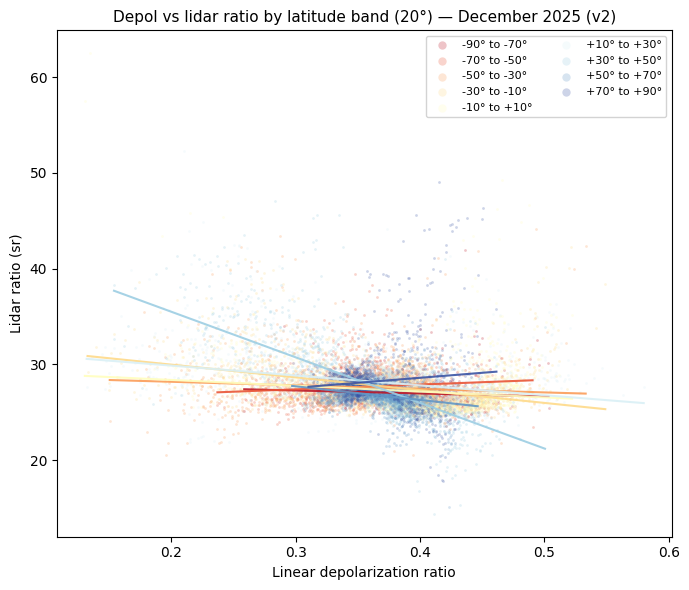

In [393]:
import matplotlib.cm as cm

LAT_EDGES = np.arange(-90, 91, 20)   # −90, −70, ..., 70, 90  → 9 bands
n_bands   = len(LAT_EDGES) - 1
colors_lb = cm.RdYlBu(np.linspace(0.05, 0.95, n_bands))

# Expand lat to (lat, height) so we can flatten consistently with depol/lr
lat_2d = np.repeat(lat[:, np.newaxis], h_mask.sum(), axis=1)
lat_flat = lat_2d.ravel()

valid_lb = np.isfinite(d_flat) & np.isfinite(l_flat)
d_lb = d_flat[valid_lb]
l_lb = l_flat[valid_lb]
lat_lb = lat_flat[valid_lb]

fig, ax = plt.subplots(figsize=(7, 6))

print(f"{'Latitude band':<22}  {'N':>7}  {'Pearson r':>10}  {'Spearman ρ':>11}  {'LR = a·δ + b'}")
print("-" * 80)

for i, (lo, hi) in enumerate(zip(LAT_EDGES[:-1], LAT_EDGES[1:])):
    band_mask = (lat_lb >= lo) & (lat_lb < hi)
    d_b, l_b  = d_lb[band_mask], l_lb[band_mask]
    label     = f"{lo:+d}° to {hi:+d}°"
    color     = colors_lb[i]

    if len(d_b) < 10:
        print(f"  {label:<20}  {len(d_b):>7}  (too few points)")
        continue

    ax.scatter(d_b, l_b, s=4, alpha=0.25, linewidths=0, color=color, label=label)

    r_b,   _  = sp_stats.pearsonr(d_b, l_b)
    rho_b, _  = sp_stats.spearmanr(d_b, l_b)
    sl_b, ic_b, *_ = sp_stats.linregress(d_b, l_b)
    print(f"  {label:<20}  {len(d_b):>7}  {r_b:>10.4f}  {rho_b:>11.4f}  "
          f"LR = {sl_b:.1f}·δ + {ic_b:.1f}")

    x_f = np.array([d_b.min(), d_b.max()])
    ax.plot(x_f, sl_b * x_f + ic_b, color=color, linewidth=1.5, alpha=0.9)

ax.set_xlabel("Linear depolarization ratio", fontsize=10)
ax.set_ylabel("Lidar ratio (sr)", fontsize=10)
ax.legend(fontsize=8, framealpha=0.85, markerscale=3, ncol=2)
ax.set_title("Depol vs lidar ratio by latitude band (20°) — December 2025 (v2)", fontsize=11)

plt.tight_layout()
plt.savefig(OUT_DIR / "M8_depol_vs_lr_latbands.png", dpi=300, bbox_inches="tight")
print("\nSaved M8_depol_vs_lr_latbands.png")
plt.show()